# 📈 Insurance KPI Forecasting Model
**Indicators:** Primes Acquises · Coût Sinistres · Nombre Sinistres · Taux de Résiliation · S/P Ratio · Impayés · Commission

**Models:** Prophet (baseline) · SARIMA · XGBoost (ML) · LSTM (Deep Learning)

---

## 0. Setup & Imports

In [38]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Time-series
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

print('✅ All libraries loaded')

✅ All libraries loaded


## 1. Data Loading & KPI Construction

In [39]:
# ── Load raw tables ──────────────────────────────────────────────────────────
import os
def load(name, date_cols=None):
    # Always resolve path to absolute data directory
    base_path = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw'
    file_path = os.path.join(base_path, f'DWH_{name}.csv')
    df = pd.read_csv(file_path, sep=None)
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    if date_cols:
        for c in date_cols:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

emission    = load('FACT_EMISSION',        ['DATE_EMISSION', 'DATE_EFFET', 'DATE_ECHEANCE'])
sinistre    = load('FACT_SINISTRE',        ['DATE_SURVENANCE', 'DATE_DECLARATION'])
annulation  = load('FACT_ANNULATION',      ['DATE_ANNULATION', 'DATE_EMISSION'])
impaye      = load('FACT_IMPAYE',          ['DATE_EMISSION'])

print(f'Emission  : {len(emission):,} rows | {emission.DATE_EMISSION.min().date()} → {emission.DATE_EMISSION.max().date()}')
print(f'Sinistre  : {len(sinistre):,} rows | {sinistre.DATE_SURVENANCE.min().date()} → {sinistre.DATE_SURVENANCE.max().date()}')
print(f'Annulation: {len(annulation):,} rows')
print(f'Impayé    : {len(impaye):,} rows')

Emission  : 65,000 rows | 2017-12-03 → 2025-12-31
Sinistre  : 8,000 rows | 2020-01-01 → 2024-12-31
Annulation: 1,273 rows
Impayé    : 868 rows


In [40]:
# ── Build monthly KPI table ───────────────────────────────────────────────────

# 1. Primes Acquises (net + taxes)
emission['PRIMES_ACQUISES'] = emission['MT_PTT'].fillna(emission['MT_PNET'].fillna(0))
emission['PERIODE'] = emission['DATE_EMISSION'].dt.to_period('M')

monthly_emission = (
    emission
    .groupby('PERIODE')
    .agg(
        PRIMES_ACQUISES=('PRIMES_ACQUISES', 'sum'),
        NB_QUITTANCES=('NUM_QUITTANCE', 'count'),
        MT_COMMISSION=('MT_COMMISSION', 'sum'),
        MT_PNET=('MT_PNET', 'sum'),
    )
    .reset_index()
)

# 2. Coût & Nombre Sinistres
sinistre['PERIODE'] = sinistre['DATE_SURVENANCE'].dt.to_period('M')

monthly_sinistre = (
    sinistre
    .groupby('PERIODE')
    .agg(
        COUT_SINISTRES=('MT_PAYE', 'sum'),
        NB_SINISTRES=('NUM_SINISTRE', 'count'),
        MT_EVALUATION=('MT_EVALUATION', 'sum'),
    )
    .reset_index()
)

# 3. Taux de Résiliation (cancellations / active policies)
annulation['PERIODE'] = annulation['DATE_ANNULATION'].dt.to_period('M')

monthly_annulation = (
    annulation
    .groupby('PERIODE')
    .agg(NB_RESILIATIONS=('NUM_QUITTANCE', 'count'))
    .reset_index()
)

# 4. Impayés
impaye['PERIODE'] = impaye['DATE_EMISSION'].dt.to_period('M')

monthly_impaye = (
    impaye
    .groupby('PERIODE')
    .agg(
        MT_IMPAYE=('MT_PTT', 'sum'),
        NB_IMPAYES=('NUM_QUITTANCE', 'count'),
    )
    .reset_index()
)

# 5. Merge all
kpi = (
    monthly_emission
    .merge(monthly_sinistre, on='PERIODE', how='left')
    .merge(monthly_annulation, on='PERIODE', how='left')
    .merge(monthly_impaye, on='PERIODE', how='left')
)

kpi = kpi.fillna(0)
kpi['DATE'] = kpi['PERIODE'].dt.to_timestamp()

# Derived KPIs
kpi['SP_RATIO']        = np.where(kpi['PRIMES_ACQUISES'] > 0, kpi['COUT_SINISTRES'] / kpi['PRIMES_ACQUISES'], 0)
kpi['TAUX_RESILIATION'] = np.where(kpi['NB_QUITTANCES'] > 0, kpi['NB_RESILIATIONS'] / kpi['NB_QUITTANCES'], 0)
kpi['TAUX_IMPAYE']     = np.where(kpi['PRIMES_ACQUISES'] > 0, kpi['MT_IMPAYE'] / kpi['PRIMES_ACQUISES'], 0)

# Filter to reliable range (2020+)
kpi = kpi[kpi['DATE'] >= '2020-01-01'].reset_index(drop=True)

print(f'KPI table: {len(kpi)} monthly rows | {kpi.DATE.min().date()} → {kpi.DATE.max().date()}')
kpi[['DATE','PRIMES_ACQUISES','COUT_SINISTRES','NB_SINISTRES','TAUX_RESILIATION','SP_RATIO']].tail(6)

KPI table: 72 monthly rows | 2020-01-01 → 2025-12-01


,DATE,PRIMES_ACQUISES,COUT_SINISTRES,NB_SINISTRES,TAUX_RESILIATION,SP_RATIO
66,2025-07-01,1.561700e+06,0.0,0.0,0.0,0.0
67,2025-08-01,1.231424e+06,0.0,0.0,0.0,0.0
68,2025-09-01,1.505807e+06,0.0,0.0,0.0,0.0
69,2025-10-01,1.789264e+06,0.0,0.0,0.0,0.0
70,2025-11-01,1.427378e+06,0.0,0.0,0.0,0.0
71,2025-12-01,7.358928e+05,0.0,0.0,0.0,0.0


## 2. Exploratory Analysis — KPI Dashboard

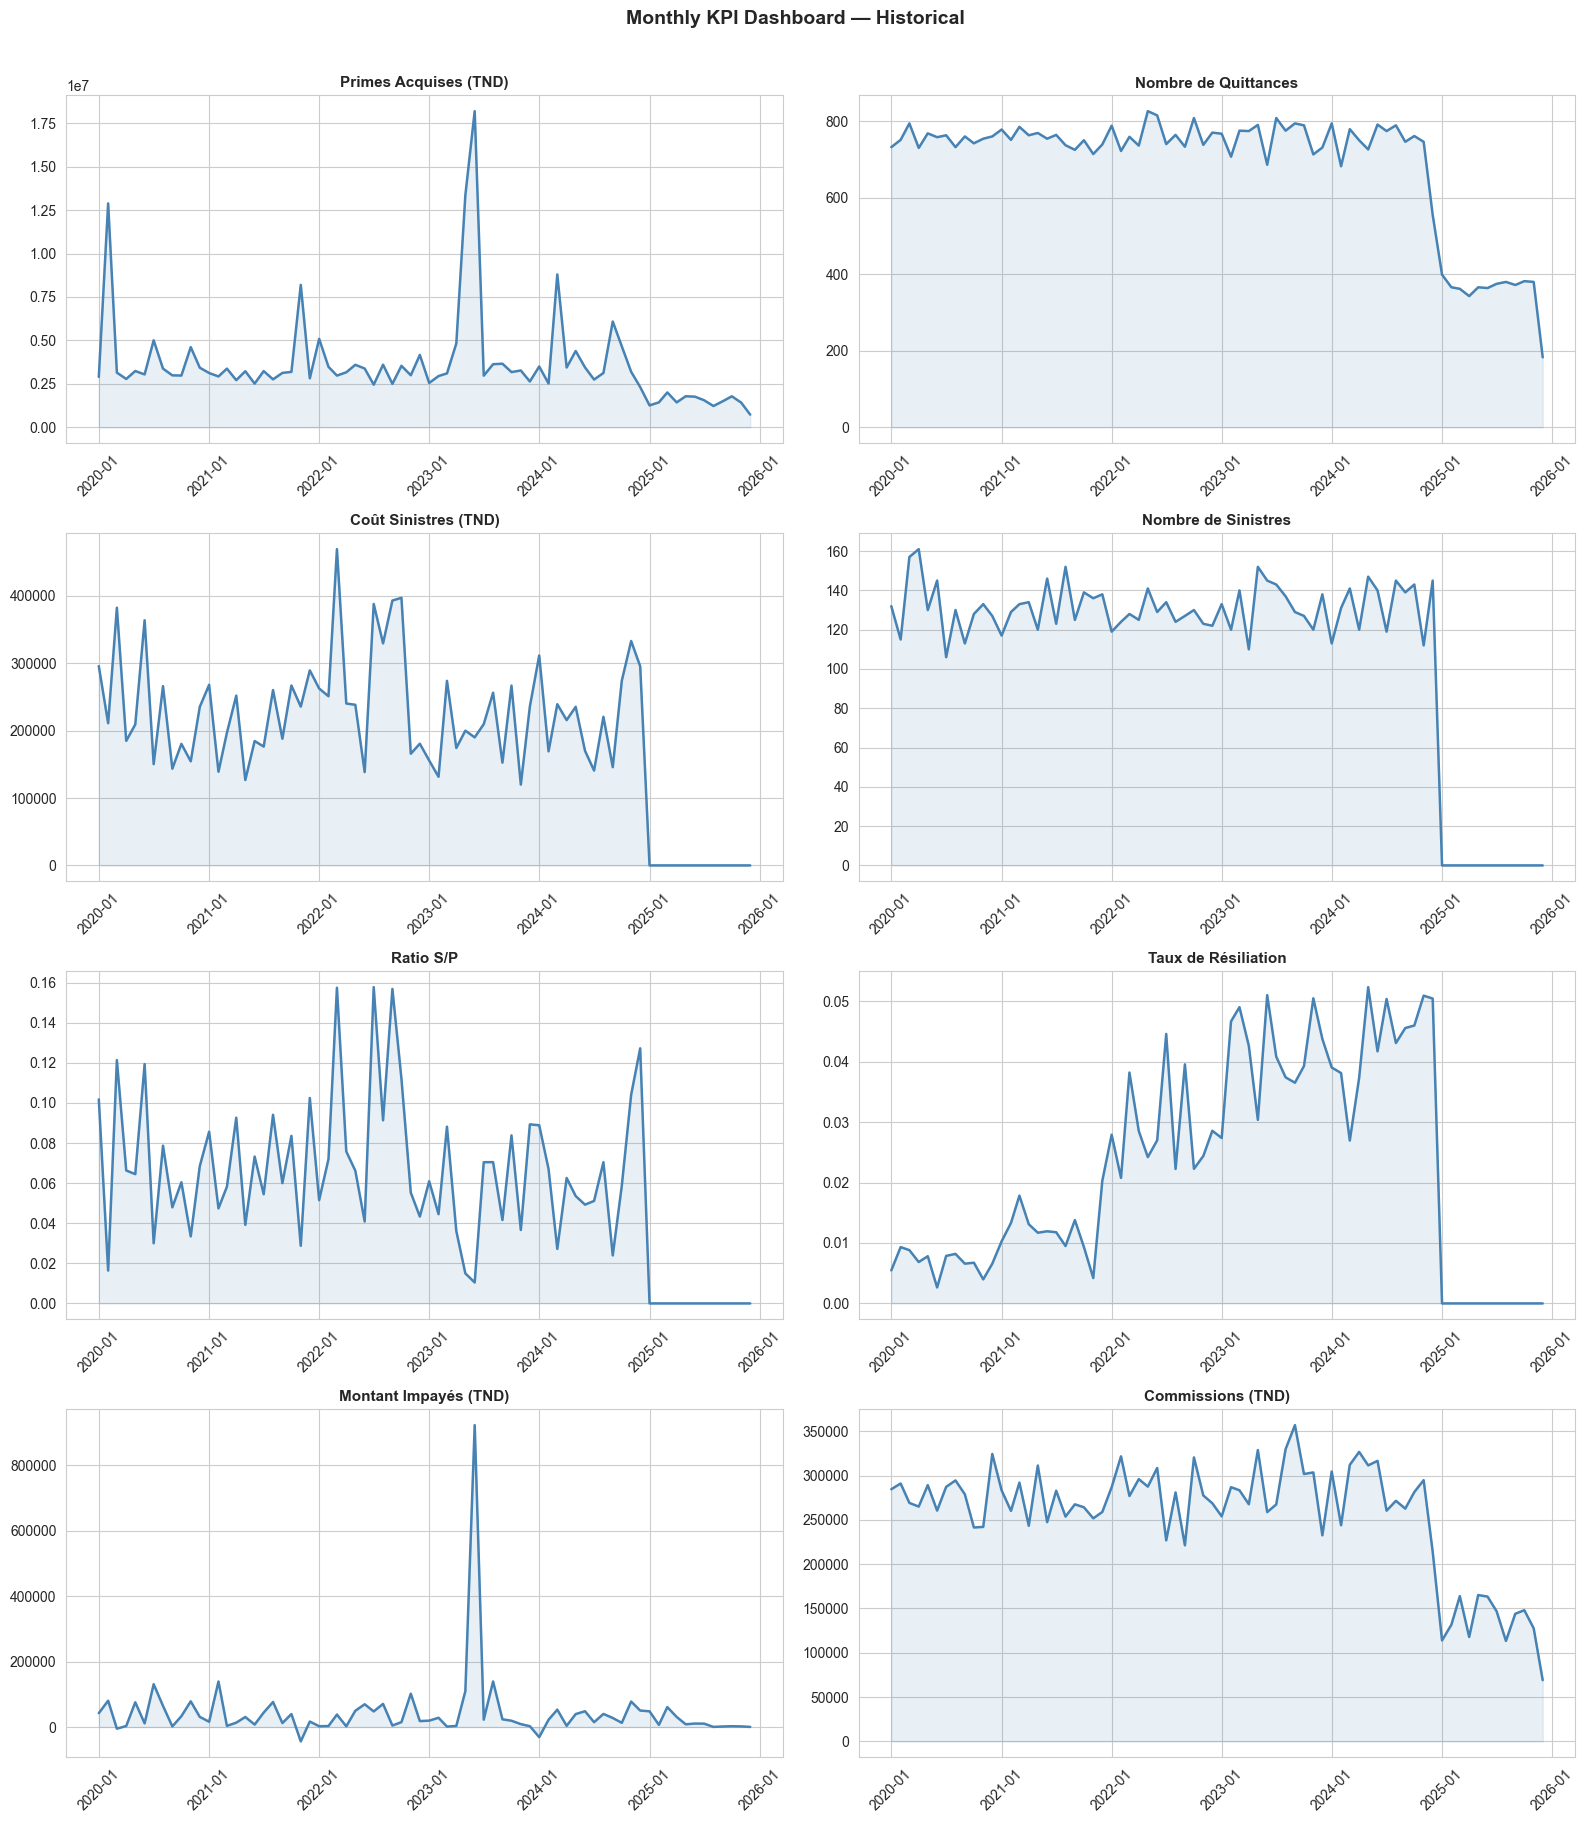

In [41]:
indicators = {
    'PRIMES_ACQUISES':  'Primes Acquises (TND)',
    'NB_QUITTANCES':    'Nombre de Quittances',
    'COUT_SINISTRES':   'Coût Sinistres (TND)',
    'NB_SINISTRES':     'Nombre de Sinistres',
    'SP_RATIO':         'Ratio S/P',
    'TAUX_RESILIATION': 'Taux de Résiliation',
    'MT_IMPAYE':        'Montant Impayés (TND)',
    'MT_COMMISSION':    'Commissions (TND)',
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
for ax, (col, title) in zip(axes.flat, indicators.items()):
    ax.plot(kpi['DATE'], kpi[col], color='steelblue', linewidth=1.8)
    ax.fill_between(kpi['DATE'], kpi[col], alpha=0.12, color='steelblue')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Monthly KPI Dashboard — Historical', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Stationarity & Decomposition

In [42]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stationary = result[1] < 0.05
    print(f'{name:30s} | p-value={result[1]:.4f} | {"✅ Stationary" if stationary else "⚠️  Non-Stationary"}')

print('=== Augmented Dickey-Fuller Test ===')
for col in ['PRIMES_ACQUISES', 'COUT_SINISTRES', 'NB_SINISTRES', 'TAUX_RESILIATION', 'SP_RATIO']:
    adf_test(kpi[col], col)

=== Augmented Dickey-Fuller Test ===
PRIMES_ACQUISES                | p-value=0.0000 | ✅ Stationary
COUT_SINISTRES                 | p-value=0.1798 | ⚠️  Non-Stationary
NB_SINISTRES                   | p-value=0.9240 | ⚠️  Non-Stationary
TAUX_RESILIATION               | p-value=0.4215 | ⚠️  Non-Stationary
SP_RATIO                       | p-value=0.0263 | ✅ Stationary


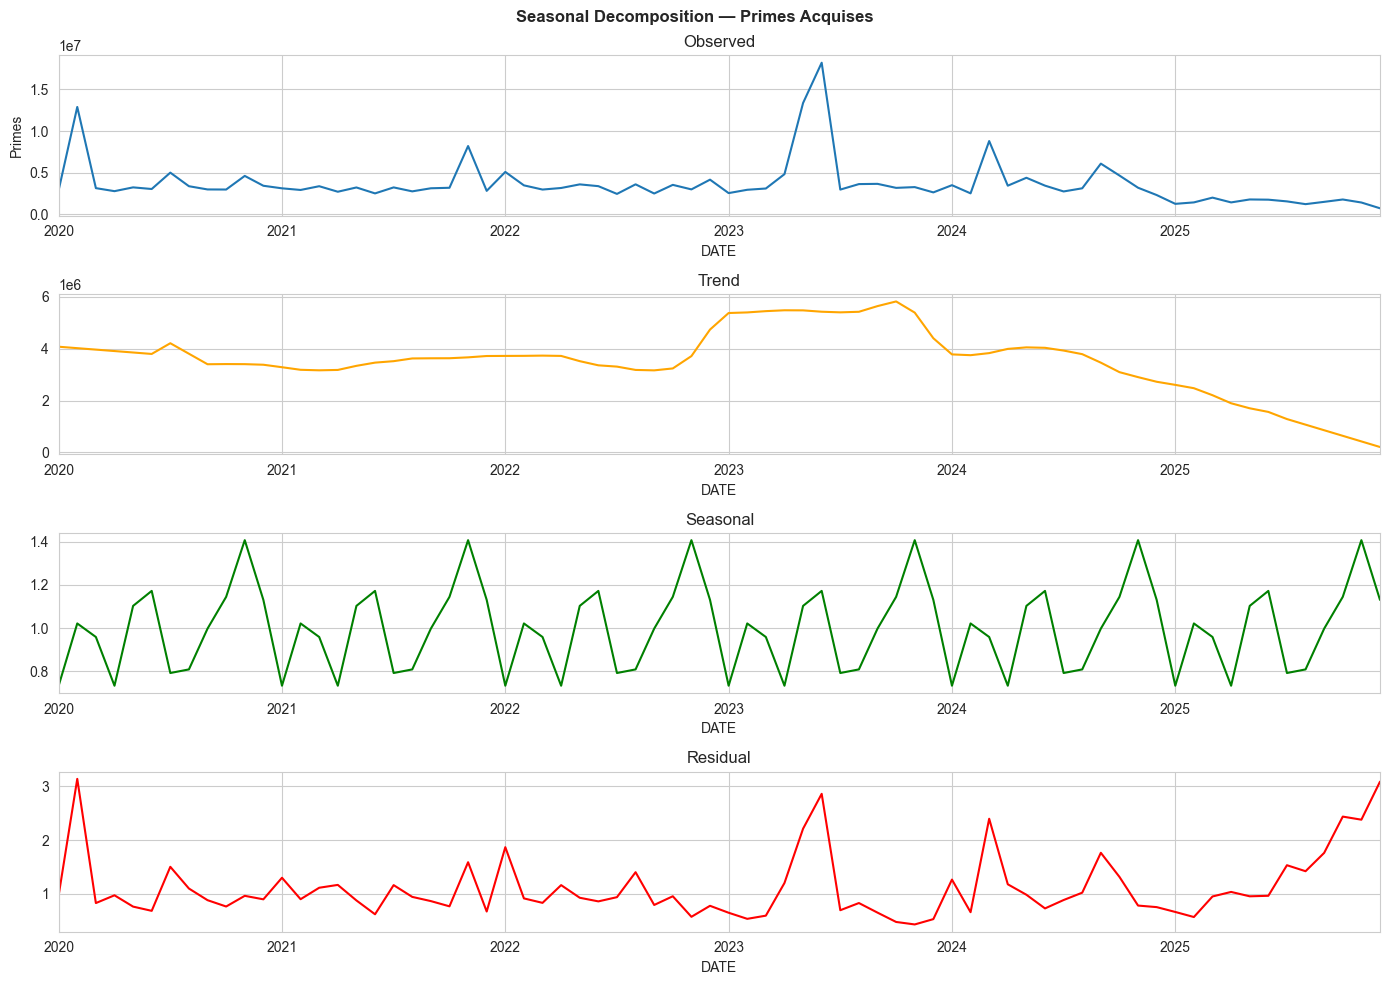

In [43]:
# Seasonal decomposition on Primes Acquises
ts = kpi.set_index('DATE')['PRIMES_ACQUISES']
ts = ts[ts > 0]  # drop zero months

decomp = seasonal_decompose(ts, model='multiplicative', period=12, extrapolate_trend='freq')
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=ax1, title='Observed'); ax1.set_ylabel('Primes')
decomp.trend.plot(ax=ax2, title='Trend', color='orange')
decomp.seasonal.plot(ax=ax3, title='Seasonal', color='green')
decomp.resid.plot(ax=ax4, title='Residual', color='red')
plt.suptitle('Seasonal Decomposition — Primes Acquises', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Forecasting Framework
We use a **multi-model** approach and compare them by MAE / RMSE / MAPE.

| Model | Strengths |
|---|---|
| **Prophet** | Holiday effects, seasonality, interpretable |
| **SARIMA** | Classical, handles autocorrelation |
| **XGBoost** | Feature-rich, captures non-linearities |
| **LSTM** | Sequence learning, long-range dependencies |

In [44]:
# ── Helpers ─────────────────────────────────────────────────────────────────

FORECAST_HORIZON = 12  # months ahead
TRAIN_CUTOFF = '2024-01-01'

def metrics(y_true, y_pred, name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'  {name:20s} MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape:.1f}%')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

def plot_forecast(history, y_test, forecasts: dict, title):
    """Plot historical + test + multiple model forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=history.index, y=history.values,
                             name='Historical', line=dict(color='steelblue', width=2)))
    fig.add_trace(go.Scatter(x=y_test.index, y=y_test.values,
                             name='Actual (test)', line=dict(color='black', width=2, dash='dot')))

    colors = ['crimson', 'orange', 'green', 'purple']
    for (name, fc), color in zip(forecasts.items(), colors):
        fig.add_trace(go.Scatter(x=fc.index, y=fc.values,
                                 name=name, line=dict(color=color, width=1.8)))

    fig.update_layout(title=title, xaxis_title='Date', yaxis_title='Value',
                      height=450, legend=dict(orientation='h', y=-0.2))
    fig.show()

TARGET = 'PRIMES_ACQUISES'  # ← change to any KPI below
ts_all = kpi.set_index('DATE')[TARGET].asfreq('MS').fillna(method='ffill')
ts_train = ts_all[ts_all.index < TRAIN_CUTOFF]
ts_test  = ts_all[ts_all.index >= TRAIN_CUTOFF]

print(f'Train: {len(ts_train)} months | Test: {len(ts_test)} months')
results_summary = []

Train: 48 months | Test: 24 months


### 4.1 Prophet

12:38:32 - cmdstanpy - INFO - Chain [1] start processing
12:38:32 - cmdstanpy - INFO - Chain [1] done processing


  Prophet              MAE=844,946,005  RMSE=1,388,306,716  MAPE=44907.5%


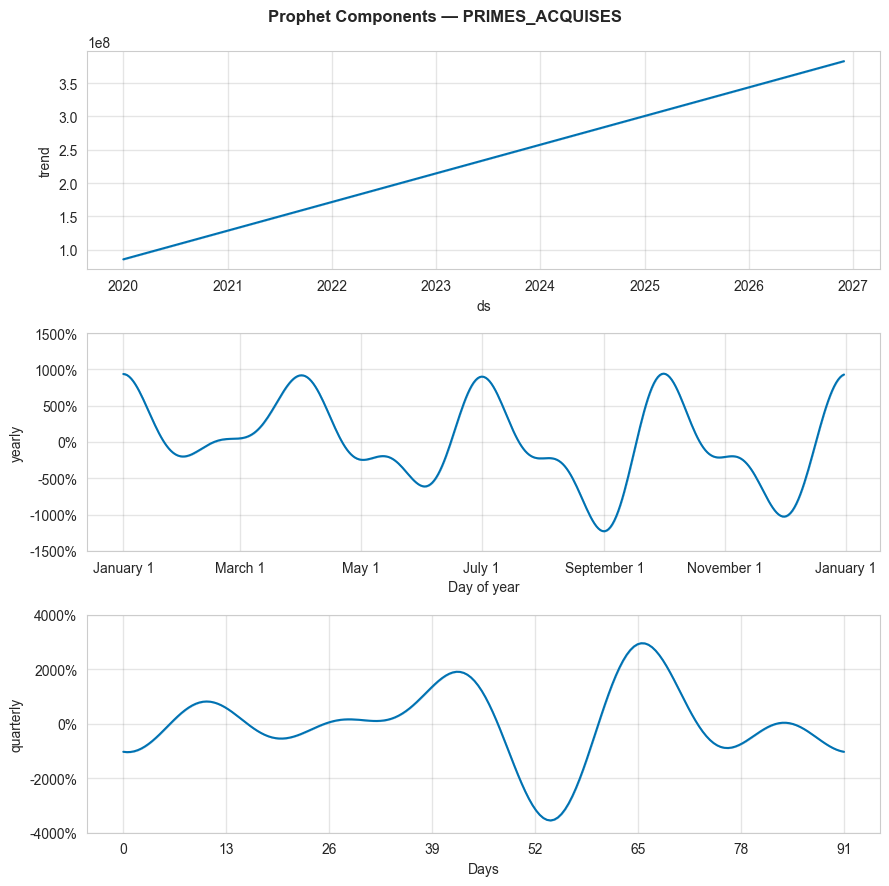

In [45]:
def run_prophet(ts_train, ts_test, horizon=12, target_name='KPI'):
    df_p = ts_train.reset_index().rename(columns={'DATE': 'ds', ts_train.name: 'y'})

    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        interval_width=0.90
    )
    m.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
    m.fit(df_p)

    # Forecast over test + horizon
    n_periods = len(ts_test) + horizon
    future = m.make_future_dataframe(periods=n_periods, freq='MS')
    forecast = m.predict(future)
    forecast = forecast.set_index('ds')['yhat']

    fc_test   = forecast.loc[ts_test.index]
    fc_future = forecast.iloc[-horizon:]

    return fc_test, fc_future, m, forecast

fc_prophet_test, fc_prophet_future, prophet_model, prophet_full = run_prophet(
    ts_train, ts_test, FORECAST_HORIZON, TARGET
)

r = metrics(ts_test, fc_prophet_test, 'Prophet')
results_summary.append(r)

# Prophet component plot
prophet_model.plot_components(
    prophet_model.predict(
        prophet_model.make_future_dataframe(periods=len(ts_test)+FORECAST_HORIZON, freq='MS')
    )
);
plt.suptitle(f'Prophet Components — {TARGET}', fontweight='bold');
plt.tight_layout(); plt.show()

### 4.2 SARIMA

In [46]:
def run_sarima(ts_train, ts_test, horizon=12,
               order=(1,1,1), seasonal_order=(1,1,1,12)):
    model = SARIMAX(ts_train, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)

    n_periods = len(ts_test) + horizon
    forecast_all = result.forecast(steps=n_periods)
    forecast_all.index = pd.date_range(
        start=ts_train.index[-1] + pd.DateOffset(months=1),
        periods=n_periods, freq='MS'
    )

    fc_test   = forecast_all.iloc[:len(ts_test)]
    fc_future = forecast_all.iloc[-horizon:]

    return fc_test, fc_future, result

fc_sarima_test, fc_sarima_future, sarima_result = run_sarima(ts_train, ts_test, FORECAST_HORIZON)

r = metrics(ts_test, fc_sarima_test, 'SARIMA')
results_summary.append(r)
print(sarima_result.summary().tables[0])

  SARIMA               MAE=4,472,660  RMSE=5,854,086  MAPE=241.3%
                                     SARIMAX Results                                      
Dep. Variable:                    PRIMES_ACQUISES   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.521
Date:                            Mon, 20 Apr 2026   AIC                            705.041
Time:                                    12:38:32   BIC                            710.264
Sample:                                01-01-2020   HQIC                           706.175
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         


### 4.3 XGBoost (feature-based)

  XGBoost              MAE=1,872,489  RMSE=2,176,654  MAPE=108.3%


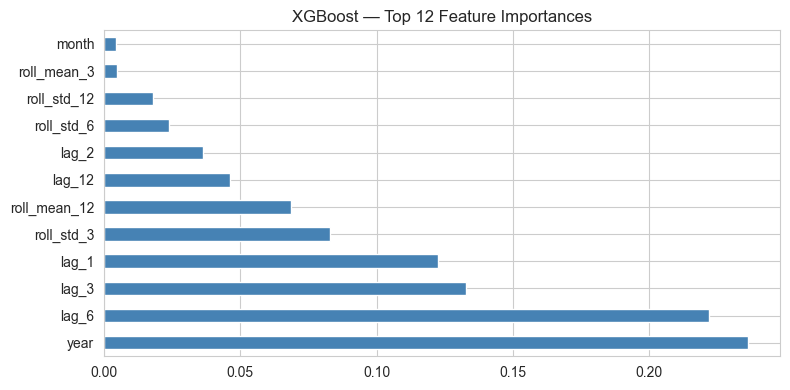

In [47]:
def create_lag_features(series, lags=[1,2,3,6,12], rolling=[3,6,12]):
    df = series.to_frame()
    col = series.name
    for lag in lags:
        df[f'lag_{lag}'] = series.shift(lag)
    for w in rolling:
        df[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
        df[f'roll_std_{w}']  = series.shift(1).rolling(w).std()
    df['month']   = series.index.month
    df['quarter'] = series.index.quarter
    df['year']    = series.index.year
    return df.dropna()

feat_df = create_lag_features(ts_all)
TARGET_COL = feat_df.columns[0]

X = feat_df.drop(columns=[TARGET_COL])
y = feat_df[TARGET_COL]

train_mask = feat_df.index < TRAIN_CUTOFF
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]

xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=30, eval_metric='rmse'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

fc_xgb_test = pd.Series(xgb_model.predict(X_test), index=X_test.index)

r = metrics(y_test, fc_xgb_test, 'XGBoost')
results_summary.append(r)

# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=X.columns).nlargest(12)
fi.plot.barh(color='steelblue', figsize=(8, 4))
plt.title('XGBoost — Top 12 Feature Importances'); plt.tight_layout(); plt.show()

### 4.4 LSTM (Deep Learning)

  Bi-LSTM              MAE=1,090,610  RMSE=1,682,295  MAPE=42.0%


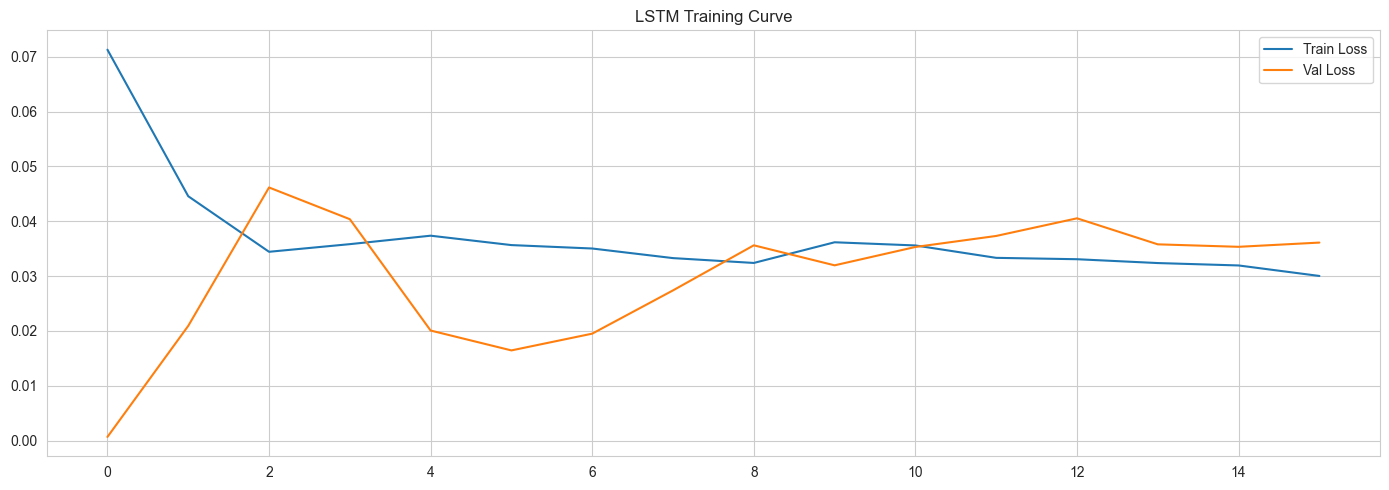

In [48]:
def build_lstm_dataset(series, window=12):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1, 1))
    X, y = [], []
    for i in range(window, len(scaled)):
        X.append(scaled[i-window:i, 0])
        y.append(scaled[i, 0])
    return np.array(X), np.array(y), scaler

WINDOW = 12
ts_values = ts_all.values
split_idx  = ts_all.index.get_loc(pd.Timestamp(TRAIN_CUTOFF))

X_lstm, y_lstm, scaler_lstm = build_lstm_dataset(ts_all, window=WINDOW)
# Adjust split
split = split_idx - WINDOW
X_tr, X_te = X_lstm[:split], X_lstm[split:]
y_tr, y_te = y_lstm[:split], y_lstm[split:]
X_tr = X_tr.reshape(-1, WINDOW, 1)
X_te = X_te.reshape(-1, WINDOW, 1)

lstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_lstm = lstm.fit(
    X_tr, y_tr, epochs=150, batch_size=8,
    validation_split=0.15, callbacks=[es], verbose=0
)

# Predictions
preds_scaled = lstm.predict(X_te, verbose=0)
preds = scaler_lstm.inverse_transform(preds_scaled).flatten()
idx_test = ts_all.index[split_idx:split_idx+len(preds)]
fc_lstm_test = pd.Series(preds, index=idx_test)

y_test_lstm = ts_all.loc[idx_test]
r = metrics(y_test_lstm, fc_lstm_test, 'Bi-LSTM')
results_summary.append(r)

# Training curve
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Curve'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Model Comparison

In [49]:
results_df = pd.DataFrame(results_summary).set_index('model')
display(results_df.style
    .highlight_min(color='lightgreen', axis=0)
    .format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'MAPE': '{:.1f}%'})
)

# Visual comparison
forecasts = {
    'Prophet': fc_prophet_test,
    'SARIMA':  fc_sarima_test,
    'XGBoost': fc_xgb_test,
    'Bi-LSTM': fc_lstm_test,
}

plot_forecast(ts_train, ts_test, forecasts, f'Model Comparison — {TARGET}')

,MAE,RMSE,MAPE
model,,,
Prophet,"844,946,005","1,388,306,716",44907.5%
SARIMA,"4,472,660","5,854,086",241.3%
XGBoost,"1,872,489","2,176,654",108.3%
Bi-LSTM,"1,090,610","1,682,295",42.0%


## 6. Best Model — 12-Month Forward Forecast

In [50]:
# ── Prophet future forecast with confidence intervals ──────────────────────
# Re-fit on ALL data (train + test)
df_full = ts_all.reset_index().rename(columns={'DATE': 'ds', TARGET: 'y'})

m_final = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.90
)
m_final.add_seasonality(name='quarterly', period=91.25, fourier_order=5)
m_final.fit(df_full)

future_df = m_final.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
fc_final = m_final.predict(future_df)

future_only = fc_final.set_index('ds').iloc[-FORECAST_HORIZON:][['yhat','yhat_lower','yhat_upper']]

fig = go.Figure()
fig.add_trace(go.Scatter(x=ts_all.index, y=ts_all.values, name='Historical',
                          line=dict(color='steelblue', width=2)))
fig.add_trace(go.Scatter(x=future_only.index, y=future_only['yhat'],
                          name='Forecast', line=dict(color='crimson', width=2.5)))
fig.add_trace(go.Scatter(
    x=pd.concat([future_only.index.to_series(), future_only.index.to_series()[::-1]]),
    y=pd.concat([future_only['yhat_upper'], future_only['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(220,50,50,0.12)',
    line=dict(color='rgba(0,0,0,0)'), name='90% CI'
))
fig.update_layout(
    title=f'📈 {TARGET} — 12-Month Forecast (Prophet)',
    xaxis_title='Date', yaxis_title='TND',
    height=450
)
fig.show()

print('\n12-Month Forecast:')
display(future_only.rename(columns={'yhat':'Prévision','yhat_lower':'Borne Inf','yhat_upper':'Borne Sup'})
        .style.format('{:,.0f}'))

12:38:37 - cmdstanpy - INFO - Chain [1] start processing
12:38:37 - cmdstanpy - INFO - Chain [1] done processing



12-Month Forecast:


,Prévision,Borne Inf,Borne Sup
ds,,,
2026-01-01 00:00:00,"1,065,973","-1,940,868","4,135,588"
2026-02-01 00:00:00,"-5,475","-3,028,087","2,924,516"
2026-03-01 00:00:00,"1,123,292","-1,890,657","4,141,756"
2026-04-01 00:00:00,"517,743","-2,418,988","3,307,064"
2026-05-01 00:00:00,"744,270","-2,097,856","3,680,412"
2026-06-01 00:00:00,"1,276,173","-1,781,234","4,355,402"
2026-07-01 00:00:00,"229,137","-2,820,793","3,165,686"
2026-08-01 00:00:00,"54,131","-3,020,941","2,979,766"
2026-09-01 00:00:00,"242,064","-2,682,225","3,425,122"


## 7. Multi-KPI Forecast Loop
Forecast **all KPIs** in one go using the best model (Prophet).

In [51]:
ALL_KPIS = [
    'PRIMES_ACQUISES',
    'COUT_SINISTRES',
    'NB_SINISTRES',
    'NB_QUITTANCES',
    'TAUX_RESILIATION',
    'SP_RATIO',
    'MT_IMPAYE',
    'MT_COMMISSION',
]

all_forecasts = {}

for kpi_col in ALL_KPIS:
    ts = kpi.set_index('DATE')[kpi_col].asfreq('MS').fillna(0)
    ts = ts[ts > 0]  # keep positive only
    if len(ts) < 18:
        print(f'  ⚠️  {kpi_col}: not enough data — skipped')
        continue

    df_kpi = ts.reset_index().rename(columns={'DATE': 'ds', kpi_col: 'y'})
    mode = 'multiplicative' if ts.min() > 0 else 'additive'

    m = Prophet(seasonality_mode=mode, yearly_seasonality=True,
                weekly_seasonality=False, interval_width=0.90,
                changepoint_prior_scale=0.05)
    m.fit(df_kpi)
    future = m.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
    fc = m.predict(future)

    future_fc = fc.set_index('ds').iloc[-FORECAST_HORIZON:][['yhat','yhat_lower','yhat_upper']]
    all_forecasts[kpi_col] = future_fc
    print(f'  ✅ {kpi_col}')

# Display summary table
forecast_table = pd.DataFrame({
    kpi_col: fc['yhat']
    for kpi_col, fc in all_forecasts.items()
})
forecast_table.index = [d.strftime('%Y-%m') for d in forecast_table.index]
forecast_table.index.name = 'Période'
display(forecast_table.style.format('{:,.1f}').background_gradient(cmap='YlOrRd', axis=0))

12:38:37 - cmdstanpy - INFO - Chain [1] start processing
12:38:38 - cmdstanpy - INFO - Chain [1] done processing
12:38:38 - cmdstanpy - INFO - Chain [1] start processing


  ✅ PRIMES_ACQUISES


12:38:38 - cmdstanpy - INFO - Chain [1] done processing
12:38:38 - cmdstanpy - INFO - Chain [1] start processing


  ✅ COUT_SINISTRES


12:38:38 - cmdstanpy - INFO - Chain [1] done processing
12:38:38 - cmdstanpy - INFO - Chain [1] start processing


...

12:38:39 - cmdstanpy - INFO - Chain [1] start processing
12:38:39 - cmdstanpy - INFO - Chain [1] done processing
12:38:39 - cmdstanpy - INFO - Chain [1] start processing


  ✅ MT_IMPAYE


12:38:39 - cmdstanpy - INFO - Chain [1] done processing


  ✅ MT_COMMISSION


,PRIMES_ACQUISES,COUT_SINISTRES,NB_SINISTRES,NB_QUITTANCES,TAUX_RESILIATION,SP_RATIO,MT_IMPAYE,MT_COMMISSION
Période,,,,,,,,
2025-01,nan,"224,992.9",115.0,nan,0.1,0.1,nan,nan
2025-02,nan,"155,344.9",121.8,nan,0.1,0.0,nan,nan
2025-03,nan,"298,503.5",141.1,nan,0.1,0.1,nan,nan
2025-04,nan,"206,591.5",132.4,nan,0.1,0.1,nan,nan
2025-05,nan,"195,624.2",137.9,nan,0.1,0.0,nan,nan
2025-06,nan,"210,076.7",142.2,nan,0.1,0.1,nan,nan
2025-07,nan,"198,600.6",124.1,nan,0.1,0.1,nan,nan
2025-08,nan,"256,465.9",139.4,nan,0.1,0.1,nan,nan
2025-09,nan,"193,451.7",127.6,nan,0.1,0.1,nan,nan


## 8. Ensemble Forecast (Prophet + SARIMA + XGBoost)

In [52]:
# Simple weighted ensemble on test set for PRIMES_ACQUISES
# Weights inversely proportional to test MAPE
mapes = {r['model']: r['MAPE'] for r in results_summary if r['model'] in ['Prophet','SARIMA','XGBoost']}
inv_mapes = {m: 1/v for m, v in mapes.items()}
total = sum(inv_mapes.values())
weights = {m: v/total for m, v in inv_mapes.items()}
print('Ensemble weights:', {m: f'{w:.2%}' for m, w in weights.items()})

# Align test forecasts
idx_common = fc_sarima_test.index.intersection(fc_prophet_test.index).intersection(fc_xgb_test.index)

ensemble_test = (
    weights['Prophet'] * fc_prophet_test.loc[idx_common]
    + weights['SARIMA'] * fc_sarima_test.loc[idx_common]
    + weights['XGBoost'] * fc_xgb_test.loc[idx_common]
)

r = metrics(ts_test.loc[idx_common], ensemble_test, 'Ensemble')
results_summary.append(r)

# Final ensemble table
results_df = pd.DataFrame(results_summary).set_index('model')
display(results_df.style
    .highlight_min(color='lightgreen', axis=0)
    .format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'MAPE': '{:.1f}%'}))

Ensemble weights: {'Prophet': '0.17%', 'SARIMA': '30.93%', 'XGBoost': '68.91%'}
  Ensemble             MAE=3,496,455  RMSE=4,472,419  MAPE=212.6%


,MAE,RMSE,MAPE
model,,,
Prophet,"844,946,005","1,388,306,716",44907.5%
SARIMA,"4,472,660","5,854,086",241.3%
XGBoost,"1,872,489","2,176,654",108.3%
Bi-LSTM,"1,090,610","1,682,295",42.0%
Ensemble,"3,496,455","4,472,419",212.6%


## 9. Segment-Level Forecasting (by Branche / Produit)

12:38:39 - cmdstanpy - INFO - Chain [1] start processing
12:38:40 - cmdstanpy - INFO - Chain [1] done processing
12:38:40 - cmdstanpy - INFO - Chain [1] start processing
12:38:40 - cmdstanpy - INFO - Chain [1] done processing
12:38:40 - cmdstanpy - INFO - Chain [1] start processing
12:38:40 - cmdstanpy - INFO - Chain [1] done processing


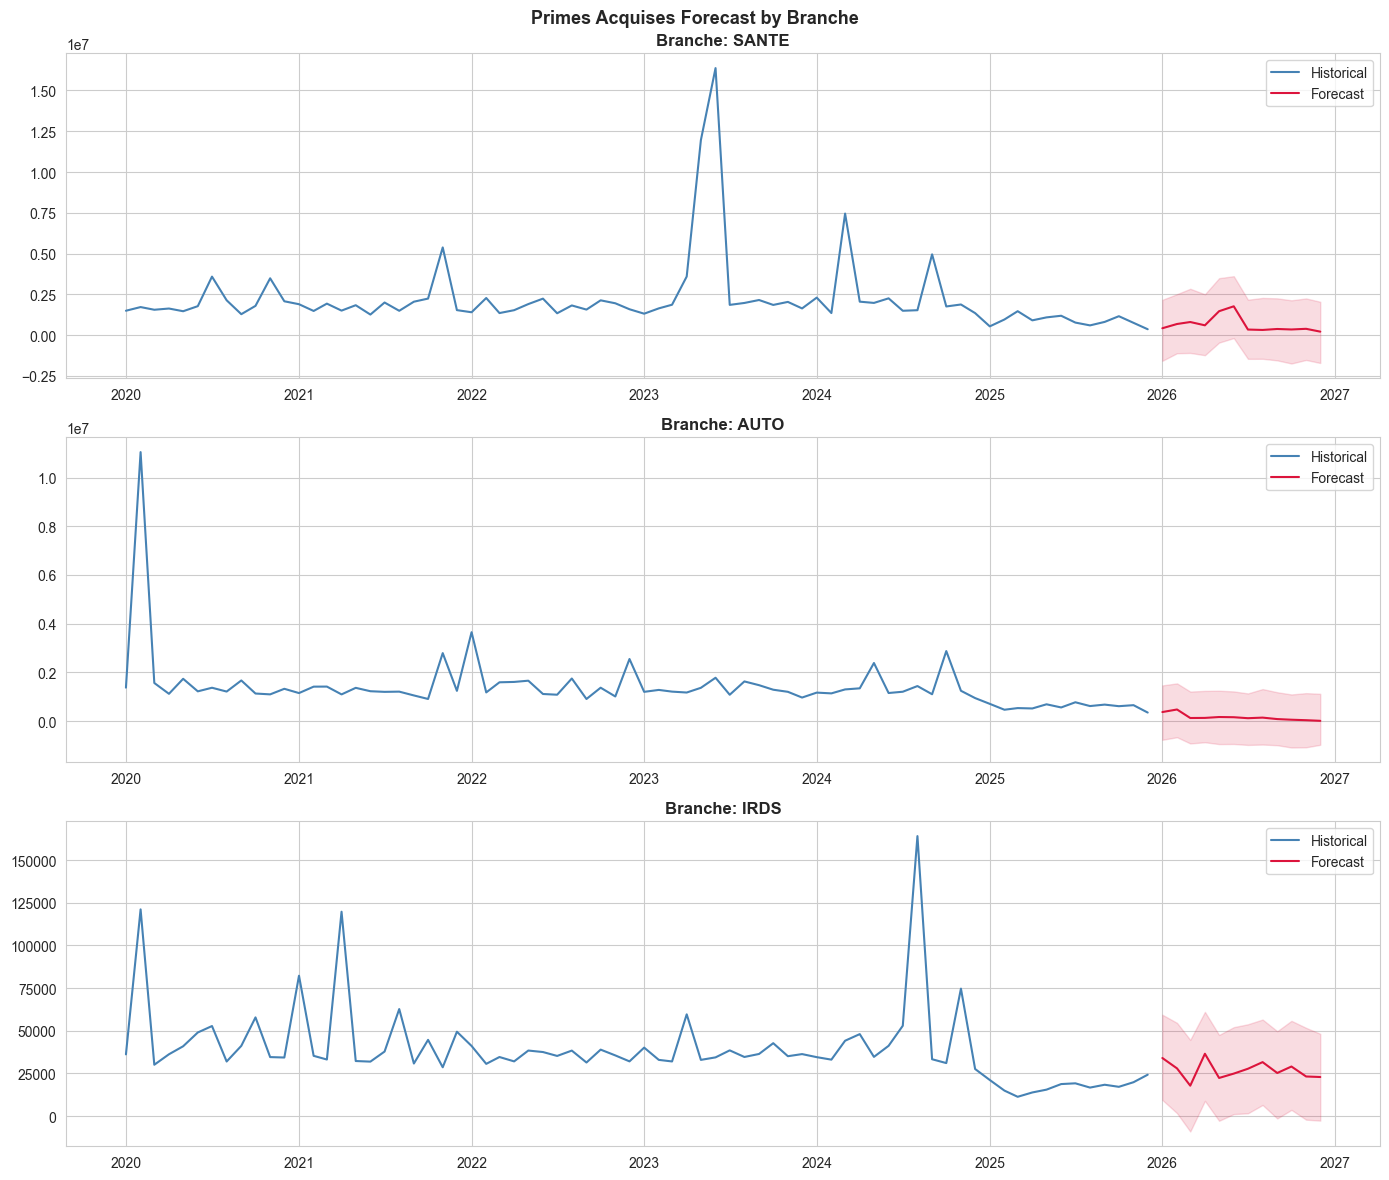

In [53]:
# Primes Acquises by Branche
emission['PERIODE'] = emission['DATE_EMISSION'].dt.to_period('M')
emission['PRIMES_ACQUISES'] = emission['MT_PTT'].fillna(emission['MT_PNET'].fillna(0))

monthly_branch = (
    emission[emission['DATE_EMISSION'] >= '2020-01-01']
    .groupby(['PERIODE', 'BRANCHE'])
    .agg(PRIMES=('PRIMES_ACQUISES', 'sum'))
    .reset_index()
)
monthly_branch['DATE'] = monthly_branch['PERIODE'].dt.to_timestamp()

top_branches = monthly_branch.groupby('BRANCHE')['PRIMES'].sum().nlargest(5).index.tolist()

branch_forecasts = {}
for branch in top_branches:
    ts_b = monthly_branch[monthly_branch['BRANCHE'] == branch].set_index('DATE')['PRIMES'].asfreq('MS').fillna(0)
    ts_b = ts_b[ts_b > 0]
    if len(ts_b) < 18:
        continue
    df_b = ts_b.reset_index().rename(columns={'DATE': 'ds', 'PRIMES': 'y'})
    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, interval_width=0.80)
    m.fit(df_b)
    fut = m.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
    fc_b = m.predict(fut).set_index('ds')
    branch_forecasts[branch] = fc_b

# Plot
fig, axes = plt.subplots(len(branch_forecasts), 1, figsize=(14, 4*len(branch_forecasts)))
if len(branch_forecasts) == 1: axes = [axes]

for ax, (branch, fc_b) in zip(axes, branch_forecasts.items()):
    ts_b = monthly_branch[monthly_branch['BRANCHE'] == branch].set_index('DATE')['PRIMES'].asfreq('MS').fillna(0)
    ax.plot(ts_b.index, ts_b.values, color='steelblue', label='Historical')
    fut_idx = fc_b.index[-FORECAST_HORIZON:]
    ax.plot(fut_idx, fc_b.loc[fut_idx, 'yhat'], color='crimson', label='Forecast')
    ax.fill_between(fut_idx, fc_b.loc[fut_idx, 'yhat_lower'], fc_b.loc[fut_idx, 'yhat_upper'],
                    alpha=0.15, color='crimson')
    ax.set_title(f'Branche: {branch}', fontweight='bold')
    ax.legend()

plt.suptitle('Primes Acquises Forecast by Branche', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()